# CONFIGURATION PARAMETERS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib.ticker import MultipleLocator
import re
import os

cb_10x = os.path.join("..", "clean-files-ul", "aggr", "agg-cb-10.csv")
cf_10x = os.path.join("..", "clean-files-ul", "aggr", "agg-cf-10.csv")
cb_5x = os.path.join("..", "clean-files-ul", "aggr", "agg-cb-5.csv")
cf_5x = os.path.join("..", "clean-files-ul", "aggr", "agg-cf-5.csv")
cb_1x = os.path.join("..", "clean-files-ul", "aggr", "agg-cb-1.csv")
cf_1x = os.path.join("..", "clean-files-ul", "aggr", "agg-cf-1.csv")

#cb_10x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cb-10.csv")
#cf_10x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cf-10.csv")
#cb_5x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cb-5.csv")
#cf_5x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cf-5.csv")
#cb_1x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cb-1.csv")
#cf_1x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cf-1.csv")

In [ ]:
df_cb_1 = pd.read_csv(cb_1x)
df_cf_1 = pd.read_csv(cf_1x)

def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (Mbps)"] = df_ue["Mean_Throughput"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_5 = read_data_by_ue(cb_5x)
dfs_cf_5 = read_data_by_ue(cf_5x)

def read_latency_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df.sort_values("Time_ms").reset_index(drop=True)
    df["Rolling Avg (us)"] = df["Mean_Latency_us"].rolling(window=5, min_periods=1).mean()

    return df

def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (Mbps)"] = df_ue["Mean_Throughput"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

def read_latency_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df.sort_values("Time_ms").reset_index(drop=True)
    df["Rolling Avg (us)"] = df["Mean_Latency_us"].rolling(window=5, min_periods=1).mean()

    return df


dfs_cb_10 = read_data_by_ue(cb_10x)
dfs_cf_10 = read_data_by_ue(cf_10x)

# DESCRIBE

In [5]:
print(df_cb_1["Mean_Throughput"].describe())
print(df_cf_1["Mean_Throughput"].describe())

count    900.000000
mean       0.514195
std        0.057486
min        0.338253
25%        0.475816
50%        0.515126
75%        0.557160
max        0.666345
Name: Mean_Throughput, dtype: float64
count    900.000000
mean       1.050203
std        0.249508
min        0.049400
25%        0.885235
50%        1.032650
75%        1.212610
max        1.958040
Name: Mean_Throughput, dtype: float64


In [ ]:
df_cb_5 = pd.read_csv(cb_5x)
df_cf_5 = pd.read_csv(cf_5x)

print(df_cb_5["Mean_Throughput"].describe())
print(df_cf_5["Mean_Throughput"].describe())

count    4500.000000
mean        0.370776
std         0.126666
min         0.060673
25%         0.268528
50%         0.354878
75%         0.465766
max         0.813157
Name: Mean_Throughput, dtype: float64
count    4498.000000
mean        0.724434
std         0.405135
min         0.000000
25%         0.428697
50%         0.684410
75%         0.981847
max         2.938360
Name: Mean_Throughput, dtype: float64


In [ ]:
df_cb_10 = pd.read_csv(cb_10x)
df_cf_10 = pd.read_csv(cf_10x)

print(df_cb_10["Mean_Throughput"].describe())
print(df_cf_10["Mean_Throughput"].describe())

count    8100.000000
mean        0.045213
std         0.039055
min         0.000000
25%         0.017793
50%         0.031749
75%         0.062423
max         0.280714
Name: Mean_Throughput, dtype: float64
count    8839.000000
mean        0.064424
std         0.102628
min         0.000000
25%         0.000000
50%         0.000000
75%         0.117535
max         0.903330
Name: Mean_Throughput, dtype: float64


# BARPLOTS

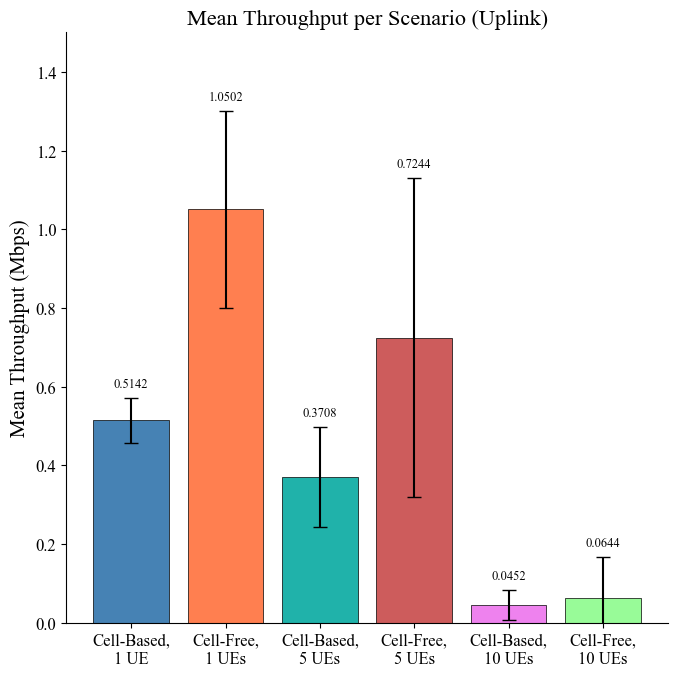

In [ ]:
mean_se_total_1 = df_cb_10['Mean_Throughput'].mean()
mean_se_total_2 = df_cb_5['Mean_Throughput'].mean()
mean_se_total_3 = df_cb_1['Mean_Throughput'].mean()
mean_se_total_41 = df_cf_10['Mean_Throughput'].mean()
mean_se_total_51 = df_cf_5['Mean_Throughput'].mean()
mean_se_total_61 = df_cf_1['Mean_Throughput'].mean()

std_se_total_1 = df_cb_10['Mean_Throughput'].std()
std_se_total_2 = df_cb_5['Mean_Throughput'].std()
std_se_total_3 = df_cb_1['Mean_Throughput'].std()
std_se_total_41 = df_cf_10['Mean_Throughput'].std()
std_se_total_51 = df_cf_5['Mean_Throughput'].std()
std_se_total_61 = df_cf_1['Mean_Throughput'].std()

mean_values = [
    mean_se_total_3,
    mean_se_total_61,
    mean_se_total_2,
    mean_se_total_51,
    mean_se_total_1,
    mean_se_total_41
]

std_values = [
    std_se_total_3,
    std_se_total_61,
    std_se_total_2,
    std_se_total_51,
    std_se_total_1,
    std_se_total_41
]

labels = [
    "Cell-Based,\n1 UE",
    "Cell-Free,\n1 UEs",
    "Cell-Based,\n5 UEs",
    "Cell-Free,\n5 UEs",
    "Cell-Based,\n10 UEs",
    "Cell-Free,\n10 UEs",
]

colors = ["steelblue", 
          "coral", 
          "lightseagreen",
          "indianred",
          "violet", 
          "palegreen",
] 

plt.figure(figsize=(7, 7))
bars = plt.bar(labels, mean_values, color=colors, yerr=std_values, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("Mean Throughput per Scenario (Uplink)")
plt.ylabel("Mean Throughput (Mbps)")
plt.ylim(0, 1.5)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + std_values[i] + 0.02,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("figs/barplot_throughput_per_scenario.pdf", dpi=300, bbox_inches="tight")
plt.show()

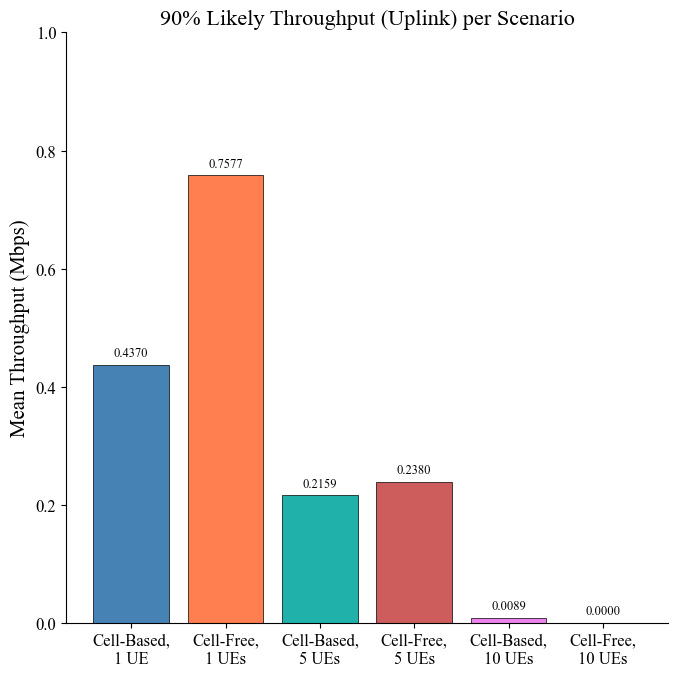

In [ ]:
p10_cf_1_aggr = df_cf_1['Mean_Throughput'].quantile(0.10)
p10_cf_5_aggr = df_cf_5['Mean_Throughput'].quantile(0.10)
p10_cf_10_aggr = df_cf_10['Mean_Throughput'].quantile(0.10)
p10_cb_1 = df_cb_1['Mean_Throughput'].quantile(0.10)
p10_cb_5 = df_cb_5['Mean_Throughput'].quantile(0.10)
p10_cb_10 = df_cb_10['Mean_Throughput'].quantile(0.10)

mean_values = [
    p10_cb_1,
    p10_cf_1_aggr,
    p10_cb_5,
    p10_cf_5_aggr,
    p10_cb_10,
    p10_cf_10_aggr,

]

labels = [
    "Cell-Based,\n1 UE",
    "Cell-Free,\n1 UEs",
    "Cell-Based,\n5 UEs",
    "Cell-Free,\n5 UEs",
    "Cell-Based,\n10 UEs",
    "Cell-Free,\n10 UEs",
]

colors = ["steelblue", 
          "coral", 
          "lightseagreen",
          "indianred",
          "violet", 
          "palegreen",
] 

plt.figure(figsize=(7, 7))
bars = plt.bar(labels, mean_values, color=colors, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("90% Likely Throughput (Uplink) per Scenario")
plt.ylabel("Mean Throughput (Mbps)")
plt.ylim(0, 1)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("figs/mean_throughput_90_uplink_cb_cf_aggr.pdf", dpi=300, bbox_inches="tight")
plt.show()

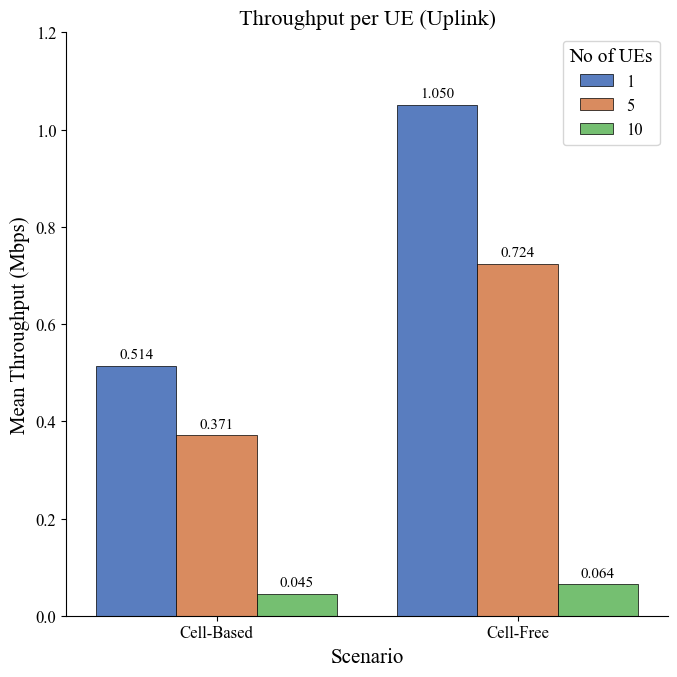

In [ ]:
data = {
    "Nº de UEs": [1, 1, 5, 5, 10, 10],
    "Cenário": ["Cell-Based", "Cell-Free",
                "Cell-Based", "Cell-Free",
                "Cell-Based", "Cell-Free",],
    "SE_total": [
        df_cb_1["Mean_Throughput"].mean(),
        df_cf_1["Mean_Throughput"].mean(),
        df_cb_5["Mean_Throughput"].mean(),
        df_cf_5["Mean_Throughput"].mean(),
        df_cb_10["Mean_Throughput"].mean(),
        df_cf_10["Mean_Throughput"].mean()
    ]
}

df_plot = pd.DataFrame(data)

plt.figure(figsize=(7, 7))
sns.barplot(
    x="Cenário",      
    y="SE_total",
    hue="Nº de UEs",   
    data=df_plot,
    palette="muted",
    edgecolor="black",
    linewidth=0.5,
)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.title("Throughput per UE (Uplink)")
plt.ylabel("Mean Throughput (Mbps)")
plt.xlabel("Scenario")
plt.legend(title="No of UEs", loc="best")
plt.ylim(0, 1.2)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center", va="bottom",
            fontsize=11, fontfamily="Times New Roman"
        )

plt.tight_layout()
plt.savefig("figs/mean_throughput_uplink_per_scenario.pdf", dpi=300, bbox_inches="tight")
plt.show()


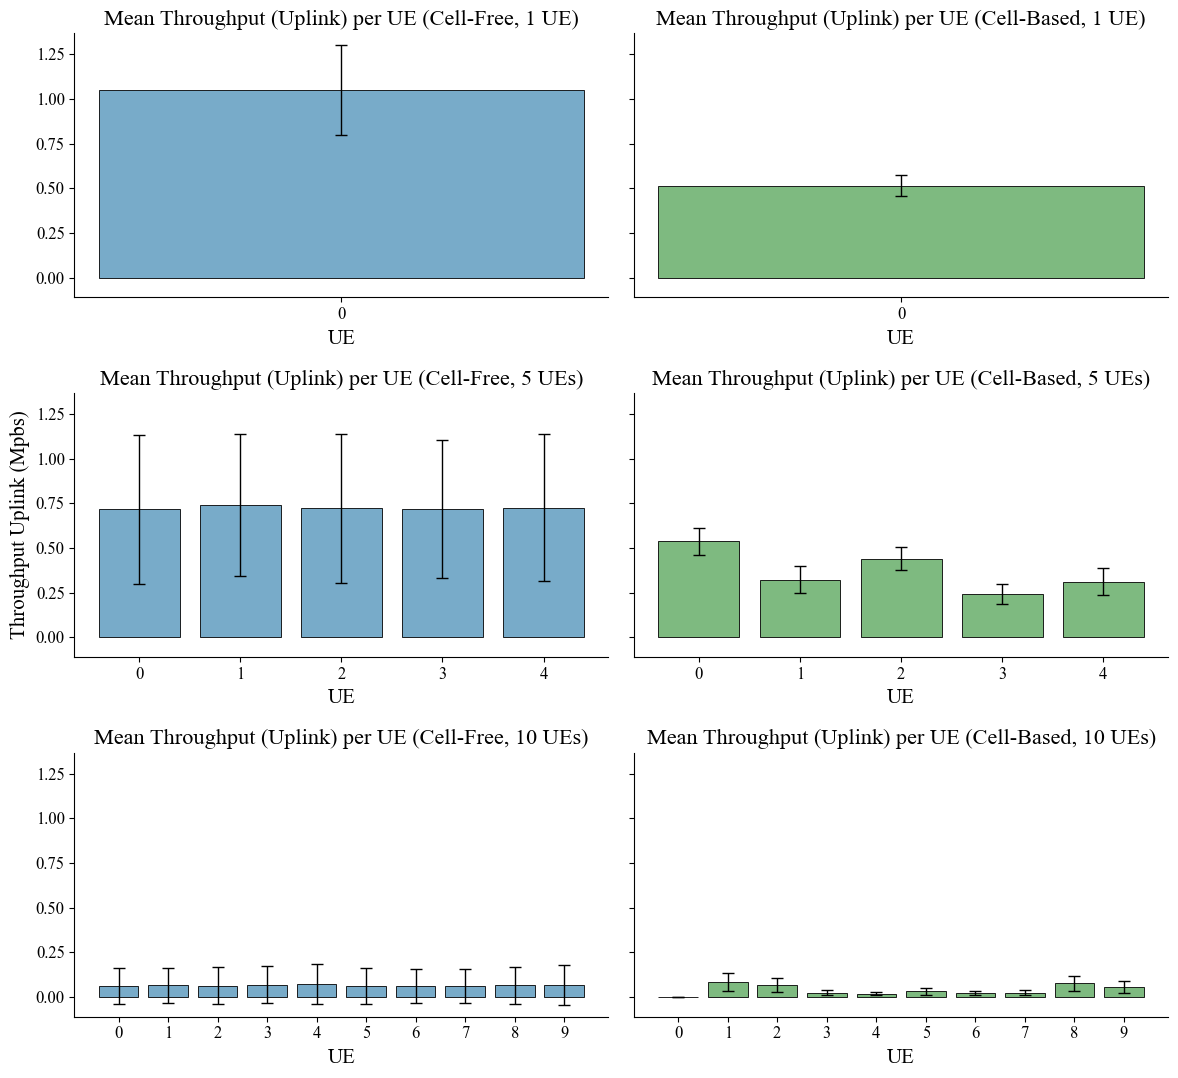

In [ ]:
import numpy as np
# CF 10x UEs
def reindex_ues(df):
    """Mapeia UE_IDs para índices sequenciais 0..N-1"""
    df = df.copy()
    df["UE_idx"] = range(len(df))
    return df

df_means_cf_10 = (df_cf_10
            .groupby("UE_ID")["Mean_Throughput"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 10x UEs
df_means_cb_10 = (df_cb_10
            .groupby("UE_ID")["Mean_Throughput"]
            .agg(mean="mean", std="std")
            .reset_index())

# CF 5x UEs
df_means_cf_5 = (df_cf_5
            .groupby("UE_ID")["Mean_Throughput"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 5x UEs
df_means_cb_5 = (df_cb_5
            .groupby("UE_ID")["Mean_Throughput"]
            .agg(mean="mean", std="std")
            .reset_index())


# CF 1x UEs
df_means_cf_1 = (df_cf_1
            .groupby("UE_ID")["Mean_Throughput"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 1x UEs
df_means_cb_1 = (df_cb_1
            .groupby("UE_ID")["Mean_Throughput"]
            .agg(mean="mean", std="std")
            .reset_index())

df_means_cb_10 = pd.concat([
        df_means_cb_10,
        pd.DataFrame({"UE_ID": [9], "mean": [0], "std": [0]})
    ], ignore_index=True)
df_means_cb_10 = df_means_cb_10.sort_values("UE_ID").reset_index(drop=True)


df_means_cf_1  = reindex_ues(df_means_cf_1)
df_means_cf_5  = reindex_ues(df_means_cf_5)
df_means_cf_10 = reindex_ues(df_means_cf_10)


fig, axes = plt.subplots(3, 2, figsize=(12,11), sharey=True)
configs = [
    (df_means_cf_1, df_means_cb_1, "1 UE"),
    (df_means_cf_5, df_means_cb_5, "5 UEs"),
    (df_means_cf_10, df_means_cb_10, "10 UEs")
]

colors = {"CF": "#6baed6", "CB": "#74c476"}

for row, (df_cf, df_cb, label) in enumerate(configs):
    # --- CF ---
    ax_cf = axes[row, 0]
    
    sns.barplot(data=df_cf,
                x="UE_ID",
                y="mean",
                color=colors["CF"], 
                edgecolor="black", 
                linewidth=0.6,
                errorbar=None, 
                ax=ax_cf)
    ax_cf.errorbar(x=np.arange(len(df_cf)), y=df_cf["mean"], yerr=df_cf["std"],
                   fmt="none", ecolor="black", elinewidth=1, capsize=4)
    ax_cf.set_xticks(np.arange(len(df_cf)))
    ax_cf.set_xticklabels([str(i) for i in range(len(df_cf))])
    ax_cf.set_title(f"Mean Throughput (Uplink) per UE (Cell-Free, {label})")
    ax_cf.set_xlabel("UE")
    if row == 1: 
        ax_cf.set_ylabel("Throughput Uplink (Mpbs)")
    else:
        ax_cf.set_ylabel("")
    ax_cf.spines["top"].set_visible(False)
    ax_cf.spines["right"].set_visible(False)
    ax_cf.grid(False)

    # --- CB ---
    ax_cb = axes[row, 1]
    sns.barplot(data=df_cb, 
                x="UE_ID", 
                y="mean",
                color=colors["CB"], 
                edgecolor="black", 
                linewidth=0.6,
                errorbar=None, 
                ax=ax_cb)
    ax_cb.errorbar(x=np.arange(len(df_cb)), y=df_cb["mean"], yerr=df_cb["std"],
                   fmt="none", ecolor="black", elinewidth=1, capsize=4)
    ax_cb.set_title(f"Mean Throughput (Uplink) per UE (Cell-Based, {label})")
    ax_cb.set_xlabel("UE")
    ax_cb.set_ylabel("")
    ax_cb.spines["top"].set_visible(False)
    ax_cb.spines["right"].set_visible(False)
    ax_cb.grid(False)
    ax_cb.set_xticks(np.arange(len(df_cb)))
    ax_cb.set_xticklabels([str(i) for i in range(len(df_cb))])

plt.tight_layout()
plt.savefig("figs/mean_throughput_uplink_total_aggr.pdf", dpi=300, bbox_inches="tight")
plt.show()

# BOXPLOTS

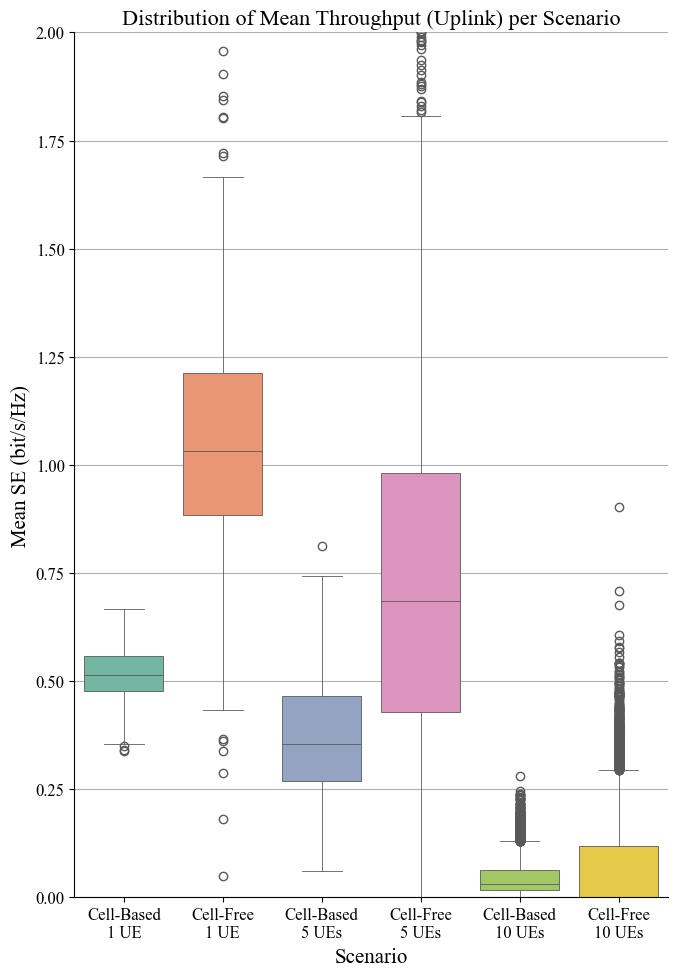

In [ ]:
df_cb_10["Scenario"] = "Cell-Based\n10 UEs"
df_cf_10["Scenario"] = "Cell-Free\n10 UEs"
df_cb_5["Scenario"] = "Cell-Based\n5 UEs"
df_cf_5["Scenario"] = "Cell-Free\n5 UEs"
df_cb_1["Scenario"] = "Cell-Based\n1 UE"
df_cf_1["Scenario"] = "Cell-Free\n1 UE"

df_all = pd.concat([df_cb_1, df_cf_1, df_cb_5, df_cf_5,  df_cb_10, df_cf_10 ], ignore_index=True)

plt.figure(figsize=(7,10))
sns.boxplot(
    x="Scenario",
    y="Mean_Throughput",
    data=df_all,
    hue="Scenario",
    palette="Set2",
    linewidth=0.6
)
plt.title("Distribution of Mean Throughput (Uplink) per Scenario")
plt.xlabel("Scenario")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 2)
plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("figs/mean_throughput_boxplot_per_scenario.pdf", dpi=300, bbox_inches="tight")
plt.show()

### outlier removal 

C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_12888\1280668142.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(drop_outliers_iqr, k=1.5))


                   before  after  removed
Scenario                                 
Cell-Based 1 UE       900    897        3
Cell-Based 10 UEs    8100   7721      379
Cell-Based 5 UEs     4500   4499        1
Cell-Free 1 UE        900    886       14
Cell-Free 10 UEs     8839   8471      368
Cell-Free 5 UEs      4498   4452       46


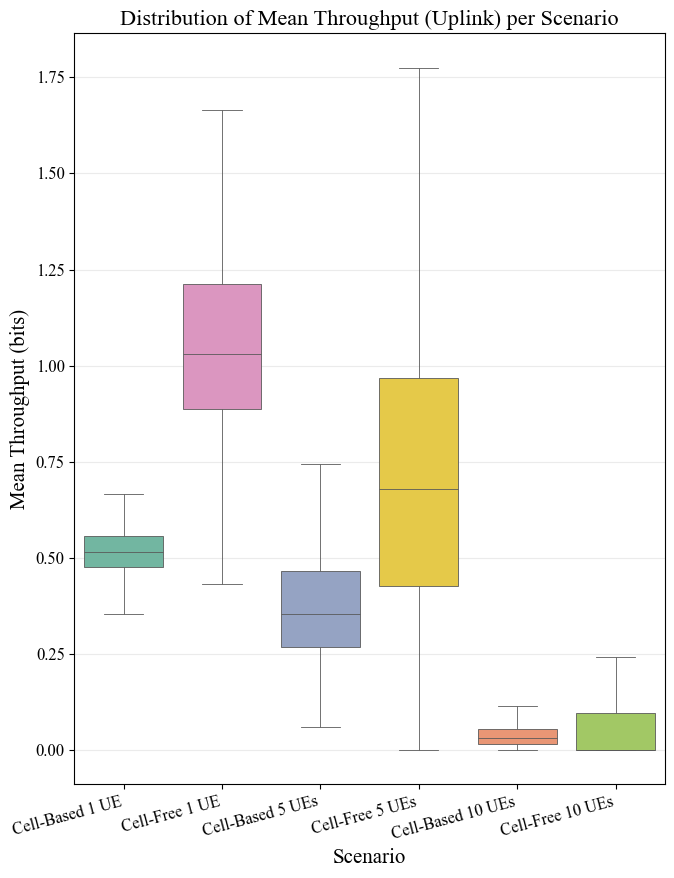

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

order = ['Cell-Based 1 UE','Cell-Free 1 UE',
         'Cell-Based 5 UEs','Cell-Free 5 UEs',
         'Cell-Based 10 UEs','Cell-Free 10 UEs']


df_long = pd.concat([
    df_cb_1.assign(Scenario="Cell-Based 1 UE")[["Scenario", "Mean_Throughput"]],
    df_cf_1.assign(Scenario="Cell-Free 1 UE")[["Scenario", "Mean_Throughput"]],
    df_cb_5.assign(Scenario="Cell-Based 5 UEs")[["Scenario", "Mean_Throughput"]],
    df_cf_5.assign(Scenario="Cell-Free 5 UEs")[["Scenario", "Mean_Throughput"]],
    df_cb_10.assign(Scenario="Cell-Based 10 UEs")[["Scenario", "Mean_Throughput"]],
    df_cf_10.assign(Scenario="Cell-Free 10 UEs")[["Scenario", "Mean_Throughput"]],
], ignore_index=True).rename(columns={"Mean_Throughput": "value"})


def drop_outliers_iqr(g, k=1.5):
    q1 = g["value"].quantile(0.25)
    q3 = g["value"].quantile(0.75)
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        return g
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return g[(g["value"] >= lo) & (g["value"] <= hi)]

before = df_long.groupby("Scenario")["value"].size()

df_clean = (df_long
            .groupby("Scenario", group_keys=False)
            .apply(drop_outliers_iqr, k=1.5))

after = df_clean.groupby("Scenario")["value"].size()
print(pd.concat([before.rename("before"), after.rename("after"),
                 (before-after).rename("removed")], axis=1))

plt.figure(figsize=(7, 9))
ax = sns.boxplot(data=df_clean, 
                 x="Scenario", 
                 y="value", 
                 hue="Scenario",
                 palette="Set2",
                 linewidth=0.6,
                 order=order, 
                 whis=1.5, 
                 showfliers=False)
ax.set_title("Distribution of Mean Throughput (Uplink) per Scenario")
ax.set_xlabel("Scenario"); ax.set_ylabel("Mean Throughput (bits)")
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("figs/mean_se_boxplot_no_outliers.pdf", dpi=300, bbox_inches="tight")
plt.show()

                    before  after  removed
Scenario                                  
Cell-Based 10x UEs    8100   7721      379
Cell-Based 1x UE       900    897        3
Cell-Based 5x UEs     4500   4499        1
Cell-Free 10x UEs     8839   8471      368
Cell-Free 1x UE        900    886       14
Cell-Free 5x UEs      4498   4452       46


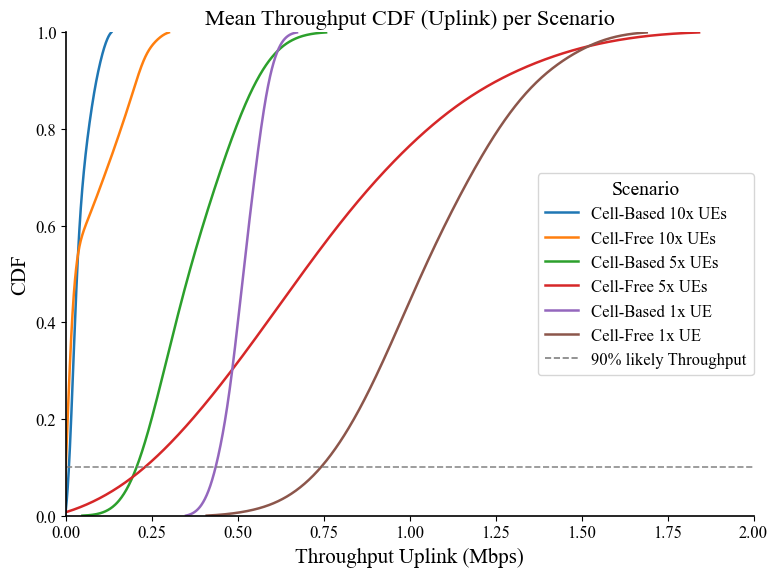

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df_cb_10["Scenario"] = "Cell-Based 10x UEs"
df_cf_10["Scenario"] = "Cell-Free 10x UEs"
df_cb_5["Scenario"]  = "Cell-Based 5x UEs"
df_cf_5["Scenario"]  = "Cell-Free 5x UEs"
df_cb_1["Scenario"]  = "Cell-Based 1x UE"
df_cf_1["Scenario"]  = "Cell-Free 1x UE"

dfs_to_plot = [
    df_cb_10[["Mean_Throughput","Scenario","UE_ID"]],
    df_cf_10[["Mean_Throughput","Scenario","UE_ID"]],
    df_cb_5[["Mean_Throughput","Scenario","UE_ID"]],
    df_cf_5[["Mean_Throughput","Scenario","UE_ID"]],
    df_cb_1[["Mean_Throughput","Scenario","UE_ID"]],
    df_cf_1[["Mean_Throughput","Scenario","UE_ID"]],
]
df_all = pd.concat(dfs_to_plot, ignore_index=True)
df_all = df_all.dropna(subset=["Mean_Throughput"]).copy()


def smooth_cdf(values, bins=400, sigma_bins=3):
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.array([]), np.array([])
    xmin, xmax = v.min(), v.max()
    pad = 0.02 * (xmax - xmin if xmax > xmin else 1.0)
    edges = np.linspace(xmin - pad, xmax + pad, bins + 1)
    counts, edges = np.histogram(v, bins=edges, density=False)
    khalf = int(4 * sigma_bins)
    kx = np.arange(-khalf, khalf + 1)
    kernel = np.exp(-0.5 * (kx / float(sigma_bins))**2)
    kernel /= kernel.sum()
    smooth_counts = np.convolve(counts, kernel, mode="same")
    cdf = np.cumsum(smooth_counts) / np.sum(smooth_counts)
    x = 0.5 * (edges[:-1] + edges[1:])
    return x, cdf


k = 1.5
g = df_all.groupby("Scenario")["Mean_Throughput"]
q1 = g.transform(lambda s: s.quantile(0.25))
q3 = g.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
lo, hi = q1 - k*iqr, q3 + k*iqr
mask = ((df_all["Mean_Throughput"] >= lo) &
        (df_all["Mean_Throughput"] <= hi)) | (iqr == 0)
df_no = df_all[mask].copy()

print(
    pd.concat(
        [
            df_all.groupby("Scenario").size().rename("before"),
            df_no.groupby("Scenario").size().rename("after")
        ],
        axis=1
    ).assign(removed=lambda d: d["before"] - d["after"])
)

order = [
    "Cell-Based 10x UEs",
    "Cell-Free 10x UEs",
    "Cell-Based 5x UEs",
    "Cell-Free 5x UEs",
    "Cell-Based 1x UE",
    "Cell-Free 1x UE",
]

pal = plt.get_cmap("tab10").colors
palette_map = {name: pal[i] for i, name in enumerate(order)}

plt.figure(figsize=(8,6))
ax = plt.gca()
for name in order:
    x, y = smooth_cdf(df_no.loc[df_no["Scenario"] == name, "Mean_Throughput"],
                      bins=500, sigma_bins=30)  
    if x.size:
        ax.plot(x, y, lw=1.8, color=palette_map[name], label=name)

y_ref = 0.1
ax.axhline(y=y_ref, ls="--", lw=1.2, color="gray", alpha=0.9)

ax.set_title("Mean Throughput CDF (Uplink) per Scenario")
ax.set_xlabel("Throughput Uplink (Mbps)")
ax.set_ylabel("CDF")
ax.set_xlim(0, 2)
ax.set_ylim(0, 1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)

handles = [Line2D([0], [0], color=palette_map[name], lw=1.8) for name in order]
labels = order + ["90% likely Throughput"]
handles.append(Line2D([0], [0], color="gray", lw=1.2, ls="--"))
ax.legend(handles, labels, title="Scenario", loc="center right", borderaxespad=0.)
plt.tight_layout()
plt.savefig("figs/mean_se_cdf_no_outliers.pdf", dpi=300, bbox_inches="tight")
plt.show()
